## Imports

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## Variables

In [2]:
# Antecedent = an INPUT (the "IF" part of the rules)
# Consequent = the OUTPUT (the "THEN" part / the decision)
dirtiness = ctrl.Antecedent(np.arange(0, 101, 1), 'dirtiness')   # 0 to 100
load      = ctrl.Antecedent(np.arange(0, 11, 1), 'load')         # 0 to 10 kg
duration  = ctrl.Consequent(np.arange(0, 61, 1), 'duration')     # 0 to 60 min

## Membership functions

In [3]:
# Membership functions: split each variable into 3 overlapping fuzzy sets.
# trimf = triangular membership function, defined by [start, peak, end].

# Dirtiness: how dirty the laundry is
dirtiness['low']    = fuzz.trimf(dirtiness.universe, [0, 0, 50])
dirtiness['medium'] = fuzz.trimf(dirtiness.universe, [0, 50, 100])
dirtiness['high']   = fuzz.trimf(dirtiness.universe, [50, 100, 100])

# Load: how big the laundry load is
load['small']  = fuzz.trimf(load.universe, [0, 0, 5])
load['medium'] = fuzz.trimf(load.universe, [0, 5, 10])
load['large']  = fuzz.trimf(load.universe, [5, 10, 10])

# Duration: recommended washing time (the output)
duration['short']  = fuzz.trimf(duration.universe, [0, 0, 30])
duration['medium'] = fuzz.trimf(duration.universe, [0, 30, 60])
duration['long']   = fuzz.trimf(duration.universe, [30, 60, 60])

## Visualize

C:\Users\odjen\Documents\Master of Computer Science\fuzzy set\fuzzy-tutorial\venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:122: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


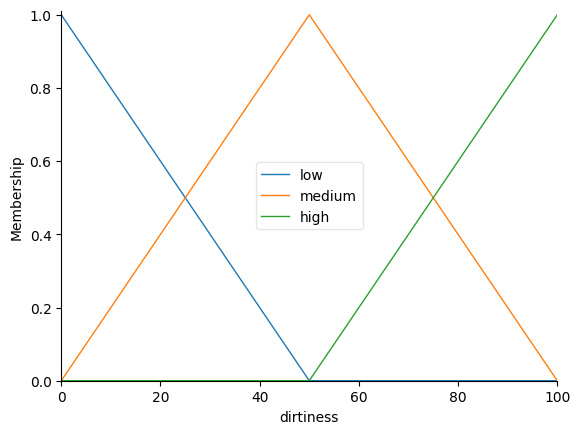

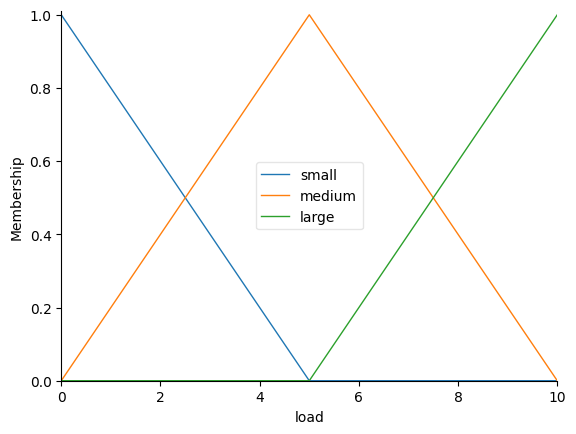

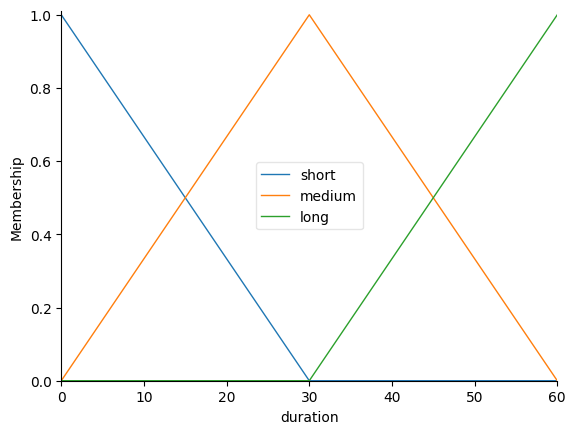

In [4]:
# Visualize the fuzzy sets of each variable
dirtiness.view()
load.view()
duration.view()

## The rules (IF...THEN)

In [6]:
# Rules: this is where we inject human expertise.
# "&" means AND, "|" means OR.
rule1 = ctrl.Rule(dirtiness['high'] | load['large'], duration['long'])
rule2 = ctrl.Rule(dirtiness['medium'] & load['medium'], duration['medium'])
rule3 = ctrl.Rule(dirtiness['low'] & load['small'], duration['short'])
rule4 = ctrl.Rule(dirtiness['low'] & load['large'], duration['medium'])# Rules: this is where we inject human expertise.
# "&" means AND, "|" means OR.
rule1 = ctrl.Rule(dirtiness['high'] | load['large'], duration['long'])
rule2 = ctrl.Rule(dirtiness['medium'] & load['medium'], duration['medium'])
rule3 = ctrl.Rule(dirtiness['low'] & load['small'], duration['short'])
rule4 = ctrl.Rule(dirtiness['low'] & load['large'], duration['medium'])

## Build the control system

In [7]:
# Assemble the rules into a control system and create a simulation to run it
washing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
washing = ctrl.ControlSystemSimulation(washing_ctrl)

## Test with a concrete situation

Recommended washing duration: 32.3 min


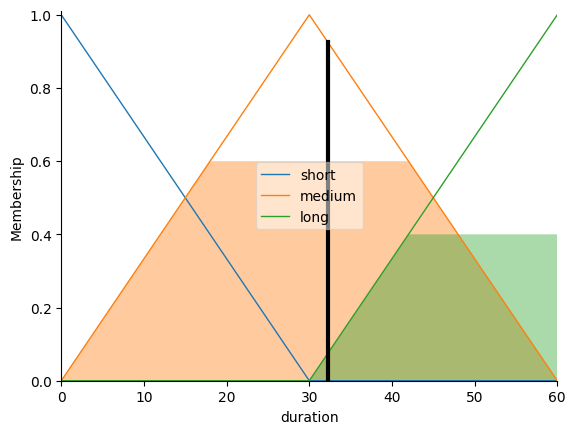

In [8]:
# Feed a concrete situation: fairly dirty laundry, medium-large load
washing.input['dirtiness'] = 70
washing.input['load'] = 6
washing.compute()

print(f"Recommended washing duration: {washing.output['duration']:.1f} min")
duration.view(sim=washing)   # shows the defuzzified output on the duration axis

In [9]:
# Test several scenarios to check the system behaves sensibly
scenarios = [
    (10, 2),    # very clean, small load   -> should be short
    (70, 6),    # quite dirty, medium load -> medium/long
    (95, 9),    # very dirty, large load   -> long
    (20, 9),    # clean but large load     -> medium
]

for d, l in scenarios:
    washing.input['dirtiness'] = d
    washing.input['load'] = l
    washing.compute()
    print(f"dirtiness={d:3d}, load={l:2d}  ->  duration = {washing.output['duration']:.1f} min")

dirtiness= 10, load= 2  ->  duration = 21.1 min
dirtiness= 70, load= 6  ->  duration = 32.3 min
dirtiness= 95, load= 9  ->  duration = 44.3 min
dirtiness= 20, load= 9  ->  duration = 35.3 min
